## Fase 2 - entrenamiento final y evaluacion sobre test (MTL U-Net)


Se entrena con **train**, se monitoriza con **val** y se evalua una sola vez sobre **test**. Como `train_one_fold` no devuelve las probabilidades de simetria/malignidad ni el modelo, tras entrenar se recargan los pesos guardados y se re-predice sobre test para obtener las probabilidades de las 3 tareas (las predicciones son identicas, mismos pesos).

Salidas: metricas finales de las 3 tareas sobre test y CSV de predicciones imagen a imagen (3 tareas con probabilidades) para el estudio estadistico.

 ## MTL - UNet + K-Fold + GradCAM

In [1]:
import os
import json
import time
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, precision_score, recall_score,
    f1_score, cohen_kappa_score,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
### Nota important:
# He eliminat ISIC_0028189 del conjunt de train, perquè era corrupta.

2026-06-24 09:33:20.857990: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1


In [2]:
train_csv  = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/train_onehot.csv"
val_csv    = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/val_onehot.csv"
test_csv   = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/test_onehot.csv"
images_dir = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/images"

IMG_SIZE    = (256, 256)   # UNet usa 256x256 
BATCH_SIZE  = 16
NUM_CLASSES = 7
N_FOLDS     = 5
class_cols  = ["dx_akiec", "dx_bcc", "dx_bkl", "dx_df", "dx_mel", "dx_nv", "dx_vasc"]
class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

# UNet no tiene CUT_LAYER (no hay backbone pretrained que descongelar)
# El entrenamiento es de una sola fase (no warmup+FT).
# EPOCHS=60 
EPOCHS  = 60
LR_INIT = 5e-4        


GRADNORM_ALPHA    = 0.5
GRADNORM_LR       = 0.025
N_TASKS           = 3
SHARED_LAYER_NAME = "shared_dense"

EXP_DIR = Path("UNet_MTL") / f"exp_{dt.datetime.now():%Y-%m-%d_%H-%M}_{N_FOLDS}fold"
EXP_DIR.mkdir(parents=True, exist_ok=True)
print(f"Experimento en: {EXP_DIR.resolve()}")

Experimento en: /home/marc/MARIADELMAR_EXPERIMENTS/MTL_experimentos/UNet_MTL/exp_2026-06-24_09-33_5fold


In [3]:
df_train = pd.read_csv(train_csv)
df_val   = pd.read_csv(val_csv)
df_test  = pd.read_csv(test_csv)
df_sym   = pd.read_csv("/home/marc/MARIADELMAR_EXPERIMENTS/ham10000_shape_symmetry_ALL.csv")

print(f"Disease CSVs   - train: {len(df_train)}  val: {len(df_val)}  test: {len(df_test)}")
print(f"Symmetry CSV   - total: {len(df_sym)}")

df_sym = df_sym.rename(columns={"image": "image_id"})
df_sym = df_sym[["image_id", "shape_symmetry"]]

MALIGN_CLASSES = ["dx_mel", "dx_bcc", "dx_akiec"]

def add_malignant_label(df):
    df = df.copy()
    df["malignant"] = df[MALIGN_CLASSES].sum(axis=1).astype(int)
    return df

df_train = add_malignant_label(df_train)
df_val   = add_malignant_label(df_val)
df_test  = add_malignant_label(df_test)

def merge_with_sym(df, name):
    before = len(df)
    merged = df.merge(df_sym, on="image_id", how="inner")
    after  = len(merged)
    lost   = before - after
    if lost > 0:
        print(f"  [WARN] {name}: perdidas {lost} imágenes sin entrada en CSV de symmetry")
    else:
        print(f"  {name}: merge OK, 0 imágenes perdidas")
    return merged

print("\nMerge con CSV de symmetry:")
df_train = merge_with_sym(df_train, "train")
df_val   = merge_with_sym(df_val,   "val")
df_test  = merge_with_sym(df_test,  "test")

for df in (df_train, df_val, df_test):
    df["filepath"] = df["image_id"].apply(lambda x: os.path.join(images_dir, f"{x}.jpg"))

# Arrays de etiquetas,disease
y_train_disease = df_train[class_cols].values.astype("float32")
y_val_disease   = df_val[class_cols].values.astype("float32")
y_test_disease  = df_test[class_cols].values.astype("float32")

# Arrays de etiquetas,symmetry
NUM_SYM_CLASSES = 3
sym_names = ["2_ejes", "1_eje", "asimetrica"]

def to_onehot_sym(df):
    y = np.zeros((len(df), NUM_SYM_CLASSES), dtype="float32")
    y[np.arange(len(df)), df["shape_symmetry"].values] = 1.0
    return y

y_train_sym = to_onehot_sym(df_train)
y_val_sym   = to_onehot_sym(df_val)
y_test_sym  = to_onehot_sym(df_test)

# Arrays de etiquetas, malignancy
NUM_MAL_CLASSES = 2
mal_names = ["benigno", "maligno"]

def to_onehot_mal(df):
    y = np.zeros((len(df), NUM_MAL_CLASSES), dtype="float32")
    y[np.arange(len(df)), df["malignant"].values] = 1.0
    return y

y_train_mal = to_onehot_mal(df_train)
y_val_mal   = to_onehot_mal(df_val)
y_test_mal  = to_onehot_mal(df_test)

# Combinar train+val para KFold
df_trainval        = pd.concat([df_train, df_val], ignore_index=True)
y_trainval_disease = np.concatenate([y_train_disease, y_val_disease], axis=0)
y_trainval_sym     = np.concatenate([y_train_sym,     y_val_sym],     axis=0)
y_trainval_mal     = np.concatenate([y_train_mal,     y_val_mal],     axis=0)

y_trainval_int     = np.argmax(y_trainval_disease, axis=1)
y_test_disease_int = np.argmax(y_test_disease, axis=1)
y_test_sym_int     = np.argmax(y_test_sym,     axis=1)
y_test_mal_int     = np.argmax(y_test_mal,     axis=1)

print("\n" + "="*60)
print("DISTRIBUCIÓN DE ETIQUETAS (train+val combinado)")
print("="*60)
print("\nDisease:")
for i, c in enumerate(class_names):
    n = (y_trainval_int == i).sum()
    print(f"  {c:<7} {n:>5}  ({100*n/len(y_trainval_int):.1f}%)")
print("\nSymmetry:")
sym_int = np.argmax(y_trainval_sym, axis=1)
for i, c in enumerate(sym_names):
    n = (sym_int == i).sum()
    print(f"  {c:<12} {n:>5}  ({100*n/len(sym_int):.1f}%)")
print("\nMalignidad:")
mal_int = np.argmax(y_trainval_mal, axis=1)
for i, c in enumerate(mal_names):
    n = (mal_int == i).sum()
    print(f"  {c:<10} {n:>5}  ({100*n/len(mal_int):.1f}%)")
print(f"\nTest set fijo: {len(df_test)} imágenes")

# Class weights para las 3 tareas
def compute_cw(y_int, n_classes):
    cw = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(n_classes),
        y=y_int,
    )
    return tf.constant(cw, dtype=tf.float32)

CW_DISEASE = compute_cw(y_trainval_int,                    NUM_CLASSES)
CW_SYM     = compute_cw(np.argmax(y_trainval_sym, axis=1), NUM_SYM_CLASSES)
CW_MAL     = compute_cw(np.argmax(y_trainval_mal, axis=1), NUM_MAL_CLASSES)

print("\nClass weights calculados:")
print(f"  disease: {CW_DISEASE.numpy().round(3)}")
print(f"  sym:     {CW_SYM.numpy().round(3)}")
print(f"  mal:     {CW_MAL.numpy().round(3)}")

Disease CSVs   — train: 6008  val: 2003  test: 2003
Symmetry CSV   — total: 10015

Merge con CSV de symmetry:
  train: merge OK, 0 imágenes perdidas
  val: merge OK, 0 imágenes perdidas
  test: merge OK, 0 imágenes perdidas

DISTRIBUCIÓN DE ETIQUETAS (train+val combinado)

Disease:
  akiec     261  (3.3%)
  bcc       411  (5.1%)
  bkl       880  (11.0%)
  df         92  (1.1%)
  mel       890  (11.1%)
  nv       5363  (66.9%)
  vasc      114  (1.4%)

Symmetry:
  2_ejes        4785  (59.7%)
  1_eje         2468  (30.8%)
  asimetrica     758  (9.5%)

Malignidad:
  benigno     6449  (80.5%)
  maligno     1562  (19.5%)

Test set fijo: 2003 imágenes

Class weights calculados:
  disease: [ 4.385  2.784  1.3   12.439  1.286  0.213 10.039]
  sym:     [0.558 1.082 3.523]
  mal:     [0.621 2.564]


2026-06-24 09:33:21.943672: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcuda.so.1
2026-06-24 09:33:21.958694: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1716] Found device 0 with properties: 
pciBusID: 0000:06:00.0 name: GeForce GTX 1080 Ti computeCapability: 6.1
coreClock: 1.582GHz coreCount: 28 deviceMemorySize: 10.92GiB deviceMemoryBandwidth: 451.17GiB/s
2026-06-24 09:33:21.958731: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1
2026-06-24 09:33:21.960403: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2026-06-24 09:33:21.961891: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcufft.so.10
2026-06-24 09:33:21.962134: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcurand.so

In [4]:
def load_image(filepath, y_disease, y_sym, y_mal):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, (y_disease, y_sym, y_mal, img)


def load_image_aug(filepath, y_disease, y_sym, y_mal):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.clip_by_value(img, 0.0, 255.0)
    img = img / 255.0
    return img, (y_disease, y_sym, y_mal, img)


def make_dataset(filepaths, y_disease, y_sym, y_mal, training=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, y_disease, y_sym, y_mal))
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths), reshuffle_each_iteration=True)
    ds = ds.map(load_image_aug if training else load_image, num_parallel_calls=15)
    ds = ds.batch(BATCH_SIZE).prefetch(50)
    return ds


test_ds = make_dataset(
    df_test["filepath"].values,
    y_test_disease, y_test_sym, y_test_mal,
    training=False,
)

print("Sanity check: un batch del test_ds")
for imgs, (yd, ys, ym, yrec) in test_ds.take(1):
    print(f"  imagen: shape={imgs.shape}  dtype={imgs.dtype}  "
          f"min={imgs.numpy().min():.2f}  max={imgs.numpy().max():.2f}")
    print(f"  y_disease: shape={yd.shape}  (esperado: (BS, 7))")
    print(f"  y_sym:     shape={ys.shape}  (esperado: (BS, 3))")
    print(f"  y_mal:     shape={ym.shape}  (esperado: (BS, 2))")
    print(f"  y_recon:   shape={yrec.shape}  (esperado: (BS, 256, 256, 3))")


Sanity check: un batch del test_ds
  imagen: shape=(16, 256, 256, 3)  dtype=<dtype: 'float32'>  min=0.03  max=1.00
  y_disease: shape=(16, 7)  (esperado: (BS, 7))
  y_sym:     shape=(16, 3)  (esperado: (BS, 3))
  y_mal:     shape=(16, 2)  (esperado: (BS, 2))
  y_recon:   shape=(16, 256, 256, 3)  (esperado: (BS, 256, 256, 3))


In [5]:
RECON_WEIGHT = 0.2


def compute_task_losses(y_true_tuple, preds,
                        cw_disease=None, cw_sym=None, cw_mal=None):
    """
    Calcula las 3 perdidas de clasificacion (cross-entropy) con class weights
    opcionales. Devuelve un tensor float32 de shape (3,).
    Solo usa las 3 primeras salidas (disease, sym, mal); la reconstruccion
    se gestiona aparte, fuera de GradNorm.
    """
    losses = []
    for i, (y_true, y_pred, cw) in enumerate(
        zip(y_true_tuple[:3], preds[:3], [cw_disease, cw_sym, cw_mal])
    ):
        l = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        if cw is not None:
            y_true_idx    = tf.argmax(y_true, axis=1)
            sample_weight = tf.gather(cw, y_true_idx)
            losses.append(tf.reduce_mean(l * sample_weight))
        else:
            losses.append(tf.reduce_mean(l))
    return tf.stack(losses)


def compute_recon_loss(y_true_img, recon_pred):
    """Perdida de reconstruccion (MSE) del decodificador."""
    return tf.reduce_mean(tf.square(y_true_img - recon_pred))


class MTLGradNormModel(tf.keras.Model):
    def __init__(self, backbone_model, **kwargs):
        super().__init__(**kwargs)
        self.backbone_model     = backbone_model
        self.shared_layer       = backbone_model.get_layer(SHARED_LAYER_NAME)
        self.task_weights       = tf.Variable(
            initial_value=tf.ones(N_TASKS, dtype=tf.float32),
            trainable=True, name="task_weights",
        )
        self.initial_losses     = tf.Variable(
            initial_value=tf.ones(N_TASKS, dtype=tf.float32),
            trainable=False, name="initial_losses",
        )
        self.initial_losses_set = tf.Variable(False, trainable=False)
        self.model_optimizer    = None
        self.weights_optimizer  = None
        self.alpha              = GRADNORM_ALPHA

    def compile_mtl(self, model_optimizer, weights_optimizer):
        self.model_optimizer   = model_optimizer
        self.weights_optimizer = weights_optimizer

    def call(self, inputs, training=False):
        return self.backbone_model(inputs, training=training)

    @property
    def shared_kernel(self):
        return self.shared_layer.kernel

    def train_step(self, data):
        imgs, y_true_tuple = data
        y_recon_true = y_true_tuple[3]
        W = self.shared_kernel

        with tf.GradientTape(persistent=True) as tape:
            preds = self.backbone_model(imgs, training=True)
            task_losses = compute_task_losses(
                y_true_tuple, preds,
                cw_disease=CW_DISEASE, cw_sym=CW_SYM, cw_mal=CW_MAL,
            )
            L0_t = task_losses[0]
            L1_t = task_losses[1]
            L2_t = task_losses[2]
            recon_loss = compute_recon_loss(y_recon_true, preds[3])
            weighted_losses = self.task_weights * task_losses
            total_loss      = tf.reduce_sum(weighted_losses) + RECON_WEIGHT * recon_loss

        model_vars  = self.backbone_model.trainable_variables
        model_grads = tape.gradient(total_loss, model_vars)
        filtered    = [(g, v) for g, v in zip(model_grads, model_vars) if g is not None]
        self.model_optimizer.apply_gradients(filtered)

        def safe_grad_norm(loss_i):
            g = tape.gradient(loss_i, W)
            if g is None:
                return tf.constant(0.0, dtype=tf.float32)
            return tf.norm(g)

        gL0 = safe_grad_norm(L0_t)
        gL1 = safe_grad_norm(L1_t)
        gL2 = safe_grad_norm(L2_t)
        grad_norms_per_loss = tf.stack([gL0, gL1, gL2])
        G_per_task = self.task_weights * grad_norms_per_loss
        del tape

        def set_initial():
            self.initial_losses.assign(task_losses)
            self.initial_losses_set.assign(True)
            return task_losses

        def keep_initial():
            return self.initial_losses

        L_zero       = tf.cond(self.initial_losses_set, keep_initial, set_initial)
        L_tilde      = task_losses / (L_zero + 1e-12)
        mean_L_tilde = tf.reduce_mean(L_tilde)
        r            = L_tilde / (mean_L_tilde + 1e-12)
        G_mean       = tf.reduce_mean(G_per_task)
        G_target     = tf.stop_gradient(G_mean * tf.pow(r, self.alpha))

        grad_norms_const = tf.stop_gradient(grad_norms_per_loss)
        with tf.GradientTape() as tape_w:
            G_reparam     = self.task_weights * grad_norms_const
            gradnorm_loss = tf.reduce_sum(tf.abs(G_reparam - G_target))
        w_grads = tape_w.gradient(gradnorm_loss, [self.task_weights])
        self.weights_optimizer.apply_gradients(zip(w_grads, [self.task_weights]))

        new_weights = self.task_weights * (
            tf.cast(N_TASKS, tf.float32) / (tf.reduce_sum(self.task_weights) + 1e-12))
        self.task_weights.assign(new_weights)

        return {
            "loss_total":    total_loss,
            "loss_disease":  task_losses[0],
            "loss_sym":      task_losses[1],
            "loss_mal":      task_losses[2],
            "loss_recon":    recon_loss,
            "w_disease":     self.task_weights[0],
            "w_sym":         self.task_weights[1],
            "w_mal":         self.task_weights[2],
            "gradnorm_loss": gradnorm_loss,
        }

    def test_step(self, data):
        imgs, y_true_tuple = data
        y_recon_true = y_true_tuple[3]
        preds       = self.backbone_model(imgs, training=False)
        task_losses = compute_task_losses(y_true_tuple, preds)
        recon_loss  = compute_recon_loss(y_recon_true, preds[3])
        weighted    = self.task_weights * task_losses
        total       = tf.reduce_sum(weighted) + RECON_WEIGHT * recon_loss
        accs = []
        for y_true, y_pred in zip(y_true_tuple[:3], preds[:3]):
            y_true_i = tf.argmax(y_true, axis=1)
            y_pred_i = tf.argmax(y_pred, axis=1)
            accs.append(tf.reduce_mean(
                tf.cast(tf.equal(y_true_i, y_pred_i), tf.float32)))
        return {
            "loss_total":   total,
            "loss_disease": task_losses[0],
            "loss_sym":     task_losses[1],
            "loss_mal":     task_losses[2],
            "loss_recon":   recon_loss,
            "acc_disease":  accs[0],
            "acc_sym":      accs[1],
            "acc_mal":      accs[2],
        }


print("MTLGradNormModel (UNet autoencoder) definido.")


MTLGradNormModel (UNet autoencoder) definido.


In [6]:
class EarlyStoppingManual:
    """Para si val_loss_unweighted no mejora en 'patience' epochs."""
    def __init__(self, patience, min_delta=0.0):
        self.patience     = patience
        self.min_delta    = min_delta
        self.best         = np.inf
        self.wait         = 0
        self.stopped      = False
        self.best_weights = None

    def on_epoch_end(self, val_loss, model):
        if val_loss < self.best - self.min_delta:
            self.best         = val_loss
            self.wait         = 0
            self.best_weights = [v.numpy() for v in model.backbone_model.weights]
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped = True

    def restore(self, model):
        if self.best_weights is not None:
            for v, w in zip(model.backbone_model.weights, self.best_weights):
                v.assign(w)


class ReduceLROnPlateauManual:
    """Reduce el LR del optimizador del modelo si val_loss_unweighted se estanca."""
    def __init__(self, optimizer, patience, factor=0.5, min_lr=1e-7):
        self.optimizer = optimizer
        self.patience  = patience
        self.factor    = factor
        self.min_lr    = min_lr
        self.best      = np.inf
        self.wait      = 0

    def on_epoch_end(self, val_loss):
        if val_loss < self.best:
            self.best = val_loss
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                current_lr = float(self.optimizer.learning_rate.numpy())
                new_lr     = max(current_lr * self.factor, self.min_lr)
                if new_lr < current_lr:
                    self.optimizer.learning_rate.assign(new_lr)
                    print(f"    [ReduceLR] lr: {current_lr:.2e} → {new_lr:.2e}")
                    self.wait = 0


def fit_mtl(model, train_ds, val_ds, epochs,
            patience_es=7, patience_lr=3, factor_lr=0.5, min_lr=1e-7,
            verbose=True):

    history = {
        "loss":      [],
        "val_loss":  [],
        "loss_disease":     [], "loss_sym":     [], "loss_mal":     [],
        "val_loss_disease": [], "val_loss_sym": [], "val_loss_mal": [],
        "val_loss_unweighted": [],
        "accuracy":     [],
        "val_accuracy": [],
        "val_acc_disease": [], "val_acc_sym": [], "val_acc_mal": [],
        "w_disease": [], "w_sym": [], "w_mal": [],
    }
    es  = EarlyStoppingManual(patience=patience_es, min_delta=0.005)
    rlr = ReduceLROnPlateauManual(
        optimizer=model.model_optimizer,
        patience=patience_lr, factor=factor_lr, min_lr=min_lr,
    )

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        train_metrics = {k: [] for k in
                         ["loss_total", "loss_disease", "loss_sym", "loss_mal",
                          "w_disease", "w_sym", "w_mal", "acc_disease"]}

        for batch in train_ds:
            imgs, y_tuple = batch
            out = model.train_step((imgs, y_tuple))
            preds = model.backbone_model(imgs, training=False)
            acc_d = tf.reduce_mean(tf.cast(
                tf.equal(tf.argmax(y_tuple[0], 1), tf.argmax(preds[0], 1)), tf.float32))
            train_metrics["acc_disease"].append(float(acc_d))
            for k in ["loss_total", "loss_disease", "loss_sym", "loss_mal",
                      "w_disease", "w_sym", "w_mal"]:
                train_metrics[k].append(float(out[k]))

        val_metrics = {k: [] for k in
                       ["loss_total", "loss_disease", "loss_sym", "loss_mal",
                        "acc_disease", "acc_sym", "acc_mal"]}
        for batch in val_ds:
            out = model.test_step(batch)
            for k in val_metrics:
                val_metrics[k].append(float(out[k]))

        tr = {k: np.mean(v) for k, v in train_metrics.items()}
        va = {k: np.mean(v) for k, v in val_metrics.items()}
        val_loss_unweighted = va["loss_disease"] + va["loss_sym"] + va["loss_mal"]

        history["loss"].append(tr["loss_total"])
        history["val_loss"].append(va["loss_total"])
        history["loss_disease"].append(tr["loss_disease"])
        history["loss_sym"].append(tr["loss_sym"])
        history["loss_mal"].append(tr["loss_mal"])
        history["val_loss_disease"].append(va["loss_disease"])
        history["val_loss_sym"].append(va["loss_sym"])
        history["val_loss_mal"].append(va["loss_mal"])
        history["val_loss_unweighted"].append(val_loss_unweighted)
        history["accuracy"].append(tr["acc_disease"])
        history["val_accuracy"].append(va["acc_disease"])
        history["val_acc_disease"].append(va["acc_disease"])
        history["val_acc_sym"].append(va["acc_sym"])
        history["val_acc_mal"].append(va["acc_mal"])
        history["w_disease"].append(tr["w_disease"])
        history["w_sym"].append(tr["w_sym"])
        history["w_mal"].append(tr["w_mal"])

        elapsed = time.time() - t0
        if verbose:
            print(f"  Epoch {epoch:3d}/{epochs} | "
                  f"loss={tr['loss_total']:.4f}  val_loss={va['loss_total']:.4f} | "
                  f"acc_d={tr['acc_disease']:.4f}  val_acc_d={va['acc_disease']:.4f} | "
                  f"val_unweighted={val_loss_unweighted:.4f} | "
                  f"w=[{tr['w_disease']:.2f},{tr['w_sym']:.2f},{tr['w_mal']:.2f}] | "
                  f"{elapsed:.0f}s")

        es.on_epoch_end(val_loss_unweighted, model)
        rlr.on_epoch_end(val_loss_unweighted)
        if es.stopped:
            print(f"    [EarlyStopping] Sin mejora en {patience_es} epochs. Parando.")
            break

    
    es.restore(model)
    if verbose:
        print(f"    [EarlyStopping] Restaurados pesos de val_loss_unw={es.best:.4f}")
    return history

In [7]:
def encoder_block(inputs, num_filters):
    x = tf.keras.layers.Conv2D(filters=num_filters, kernel_size=3,
                               activation="relu", padding="same",
                               kernel_initializer="he_normal")(inputs)
    x = tf.keras.layers.Conv2D(filters=num_filters, kernel_size=3,
                               activation="relu", padding="same",
                               kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    p = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)
    return x, p


def decoder_block(inputs, skip_features, num_filters):
    up = tf.keras.layers.UpSampling2D(size=(2, 2))(inputs)
    x  = tf.keras.layers.Conv2D(num_filters, 2, activation="relu", padding="same",
                                kernel_initializer="he_normal")(up)
    x = tf.keras.layers.concatenate([skip_features, x], axis=3)
    x = tf.keras.layers.Conv2D(num_filters, 3, activation="relu", padding="same",
                               kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(num_filters, 3, activation="relu", padding="same",
                               kernel_initializer="he_normal")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    return x


def build_model():
    inputs = tf.keras.layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
                                   name="input_image")

    c1, p1 = encoder_block(inputs, 64)
    c2, p2 = encoder_block(p1, 128)
    c3, p3 = encoder_block(p2, 256)
    c4, p4 = encoder_block(p3, 512)

    b1 = tf.keras.layers.Conv2D(filters=1024, kernel_size=3, activation="relu",
                                padding="same", kernel_initializer="he_normal",
                                name="bottleneck_conv")(p4)
    b1 = tf.keras.layers.BatchNormalization(name="bottleneck_bn")(b1)
    b1 = tf.keras.layers.Conv2D(filters=1024, kernel_size=3, activation="relu",
                                padding="same", kernel_initializer="he_normal")(b1)
    b1 = tf.keras.layers.BatchNormalization()(b1)

    e1 = decoder_block(b1, c4, 512)
    e2 = decoder_block(e1, c3, 256)
    e3 = decoder_block(e2, c2, 128)
    e4 = decoder_block(e3, c1, 64)

    final_recon = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same",
                                         kernel_initializer="he_normal")(e4)
    final_recon = tf.keras.layers.BatchNormalization()(final_recon)
    reconstruction_output = tf.keras.layers.Conv2D(3, 1, activation="relu",
                                                   padding="same",
                                                   name="reconstruction_output")(final_recon)

    x      = tf.keras.layers.GlobalAveragePooling2D(name="gap")(b1)
    shared = tf.keras.layers.Dense(256, activation="relu", name="shared_dense")(x)
    shared = tf.keras.layers.Dropout(0.3, name="shared_dropout")(shared)

    out_disease = tf.keras.layers.Dense(NUM_CLASSES,     activation="softmax",
                                        name="head_disease")(shared)
    out_sym     = tf.keras.layers.Dense(NUM_SYM_CLASSES, activation="softmax",
                                        name="head_sym")(shared)
    out_mal     = tf.keras.layers.Dense(NUM_MAL_CLASSES, activation="softmax",
                                        name="head_mal")(shared)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=[out_disease, out_sym, out_mal, reconstruction_output],
        name="MTL_UNet_autoencoder",
    )
    return model, None


In [8]:
def train_one_fold(fold_idx, train_idx, val_idx, fold_dir):
   
    fold_dir.mkdir(exist_ok=True)
    print(f"\n{'='*70}\nFOLD {fold_idx}/{N_FOLDS}  (MTL UNet, sin transfer learning)\n{'='*70}")

    df_tr  = df_trainval.iloc[train_idx].reset_index(drop=True)
    df_vl  = df_trainval.iloc[val_idx].reset_index(drop=True)
    y_tr_d = df_tr[class_cols].values.astype("float32")
    y_vl_d = df_vl[class_cols].values.astype("float32")
    y_tr_s = to_onehot_sym(df_tr)
    y_vl_s = to_onehot_sym(df_vl)
    y_tr_m = to_onehot_mal(df_tr)
    y_vl_m = to_onehot_mal(df_vl)

    print(f"  train={len(df_tr)}  val={len(df_vl)}  test(fijo)={len(df_test)}")

    train_ds = make_dataset(df_tr["filepath"].values, y_tr_d, y_tr_s, y_tr_m, training=True)
    val_ds   = make_dataset(df_vl["filepath"].values, y_vl_d, y_vl_s, y_vl_m, training=False)

    backbone, _ = build_model()
    model = MTLGradNormModel(backbone)

    model_opt   = tf.keras.optimizers.Adam(learning_rate=LR_INIT)
    weights_opt = tf.keras.optimizers.Adam(learning_rate=GRADNORM_LR)
    model.compile_mtl(model_opt, weights_opt)

    #Entrenamiento único (todo trainable desde inicio, sin warmup+FT)
    print(f"\n--- Entrenamiento UNet MTL (LR={LR_INIT}, max_epochs={EPOCHS}) ---")
    t0 = time.time()
    history = fit_mtl(model, train_ds, val_ds, epochs=EPOCHS,
                      patience_es=7, patience_lr=3)
    t_train = time.time() - t0

    pd.DataFrame(history).to_csv(fold_dir / "history.csv", index=False)

    #Plot evolución pesos GradNorm
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(history["w_disease"], label="w_disease")
    ax.plot(history["w_sym"],     label="w_sym")
    ax.plot(history["w_mal"],     label="w_mal")
    ax.axhline(1.0, color="red", ls=":", alpha=0.5, label="w inicial")
    ax.set_xlabel("epoch"); ax.set_ylabel("peso de tarea")
    ax.set_title(f"Fold {fold_idx} - Evolución pesos GradNorm (UNet MTL)")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fold_dir / "task_weights_evolution.png", dpi=100)
    plt.show()

    #Evaluación sobre test fijo
    print(f"\n--- Evaluación sobre test ({len(df_test)} imgs) ---")
    t0 = time.time()
    preds_test = model.backbone_model.predict(test_ds, verbose=0)
    t_predict  = time.time() - t0

    y_pred_d_proba, y_pred_s_proba, y_pred_m_proba = preds_test[0], preds_test[1], preds_test[2]
    y_pred_d = np.argmax(y_pred_d_proba, axis=1)
    y_pred_s = np.argmax(y_pred_s_proba, axis=1)
    y_pred_m = np.argmax(y_pred_m_proba, axis=1)

    def metrics_task(y_true_int, y_pred_int, y_pred_proba, task_name, class_labels, n_cls):
        m = {
            f"{task_name}_acc":             float((y_true_int == y_pred_int).mean()),
            f"{task_name}_balanced_acc":    float(balanced_accuracy_score(y_true_int, y_pred_int)),
            f"{task_name}_precision_macro": float(precision_score(y_true_int, y_pred_int,
                                                  average="macro", zero_division=0)),
            f"{task_name}_recall_macro":    float(recall_score(y_true_int, y_pred_int,
                                                  average="macro", zero_division=0)),
            f"{task_name}_f1_macro":        float(f1_score(y_true_int, y_pred_int,
                                                  average="macro", zero_division=0)),
            f"{task_name}_f1_weighted":     float(f1_score(y_true_int, y_pred_int,
                                                  average="weighted", zero_division=0)),
            f"{task_name}_kappa":           float(cohen_kappa_score(y_true_int, y_pred_int)),
        }
        try:
            y_true_onehot = np.eye(n_cls)[y_true_int]
            m[f"{task_name}_auc_macro"] = float(
                roc_auc_score(y_true_onehot, y_pred_proba,
                              multi_class="ovr", average="macro"))
        except Exception:
            m[f"{task_name}_auc_macro"] = float("nan")
        return m

    metrics = {
        "fold":            fold_idx,
        "time_train_s":    round(t_train, 1),
        "time_predict_s":  round(t_predict, 2),
        "epochs_trained":  len(history["loss"]),
        "final_w_disease": float(history["w_disease"][-1]),
        "final_w_sym":     float(history["w_sym"][-1]),
        "final_w_mal":     float(history["w_mal"][-1]),
    }
    metrics.update(metrics_task(y_test_disease_int, y_pred_d, y_pred_d_proba,
                                "disease", class_names, NUM_CLASSES))
    metrics.update(metrics_task(y_test_sym_int, y_pred_s, y_pred_s_proba,
                                "sym", sym_names, NUM_SYM_CLASSES))
    metrics.update(metrics_task(y_test_mal_int, y_pred_m, y_pred_m_proba,
                                "mal", mal_names, NUM_MAL_CLASSES))
    metrics["auc_melanoma"] = float(roc_auc_score(
        (y_test_disease_int == 4).astype(int), y_pred_d_proba[:, 4]))

    (fold_dir / "metrics.json").write_text(json.dumps(metrics, indent=2))

    for y_true_int, y_pred_int, names, task in [
        (y_test_disease_int, y_pred_d, class_names, "disease"),
        (y_test_sym_int,     y_pred_s, sym_names,   "sym"),
        (y_test_mal_int,     y_pred_m, mal_names,   "mal"),
    ]:
        rpt = classification_report(y_true_int, y_pred_int,
                                    target_names=names, digits=4)
        (fold_dir / f"classification_report_{task}.txt").write_text(rpt)
        print(f"\n--- {task.upper()} ---\n{rpt}")
        cm = confusion_matrix(y_true_int, y_pred_int)
        
        np.save(fold_dir / f"confusion_matrix_{task}.npy", cm)
        fig, ax = plt.subplots(figsize=(7, 5))
        ConfusionMatrixDisplay(cm, display_labels=names).plot(
            ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
        ax.set_title(f"Fold {fold_idx} - {task} (test)")
        plt.tight_layout()
        plt.savefig(fold_dir / f"confusion_matrix_{task}.png", dpi=100)
        plt.show()

    backbone.save_weights(str(fold_dir / "best_weights"), save_format="tf")
    print(f"  Pesos guardados en: {fold_dir / 'best_weights'}")

    return {
        "metrics":        metrics,
        "history":        history,
        "y_pred_d":       y_pred_d,
        "y_pred_d_proba": y_pred_d_proba,
        "y_pred_s":       y_pred_s,
        "y_pred_m":       y_pred_m,
    }

train=6008  val=2003  test=2003

FOLD 1/5  (MTL UNet, sin transfer learning)
  train=6008  val=2003  test(fijo)=2003

--- Entrenamiento UNet MTL (LR=0.0005, max_epochs=60) ---


2026-06-24 09:33:24.309864: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudnn.so.7
2026-06-24 09:33:25.787592: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2026-06-24 09:33:27.638025: W tensorflow/core/common_runtime/bfc_allocator.cc:246] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.70GiB with freed_by_count=0. The caller indicates that this is not a failure, but may mean that there could be performance gains if more memory were available.
2026-06-24 09:33:30.681731: W tensorflow/core/common_runtime/bfc_allocator.cc:246] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.69GiB with freed_by_count=0. The caller indicates that this is not a failure, but may mean that there could be performance gains if more memory were available.
2026-06-24 09:33:32.232514: W tensorflow/core/common_runtime/bfc_allocator.cc:246] Allocator (GPU_0_bfc) r

  Epoch   1/60 | loss=3.1628  val_loss=3.0165 | acc_d=0.1438  val_acc_d=0.2912 | val_unweighted=3.5907 | w=[0.57,1.03,1.40] | 629s
  Epoch   2/60 | loss=2.7799  val_loss=4.2796 | acc_d=0.3361  val_acc_d=0.6640 | val_unweighted=4.6448 | w=[0.50,1.05,1.45] | 628s
  Epoch   3/60 | loss=2.7352  val_loss=2.5658 | acc_d=0.3630  val_acc_d=0.4489 | val_unweighted=3.0766 | w=[0.47,1.11,1.42] | 630s
  Epoch   4/60 | loss=2.6253  val_loss=2.7478 | acc_d=0.4629  val_acc_d=0.6060 | val_unweighted=3.0616 | w=[0.45,1.11,1.43] | 630s
  Epoch   5/60 | loss=2.5977  val_loss=3.2652 | acc_d=0.4789  val_acc_d=0.5266 | val_unweighted=3.6684 | w=[0.45,1.17,1.39] | 629s
  Epoch   6/60 | loss=2.5600  val_loss=3.3977 | acc_d=0.4586  val_acc_d=0.5618 | val_unweighted=3.7810 | w=[0.42,1.21,1.37] | 629s
  Epoch   7/60 | loss=2.5405  val_loss=2.8897 | acc_d=0.4267  val_acc_d=0.4355 | val_unweighted=3.7501 | w=[0.40,1.23,1.37] | 630s
    [ReduceLR] lr: 5.00e-04 → 2.50e-04
  Epoch   8/60 | loss=2.4692  val_loss=3.029

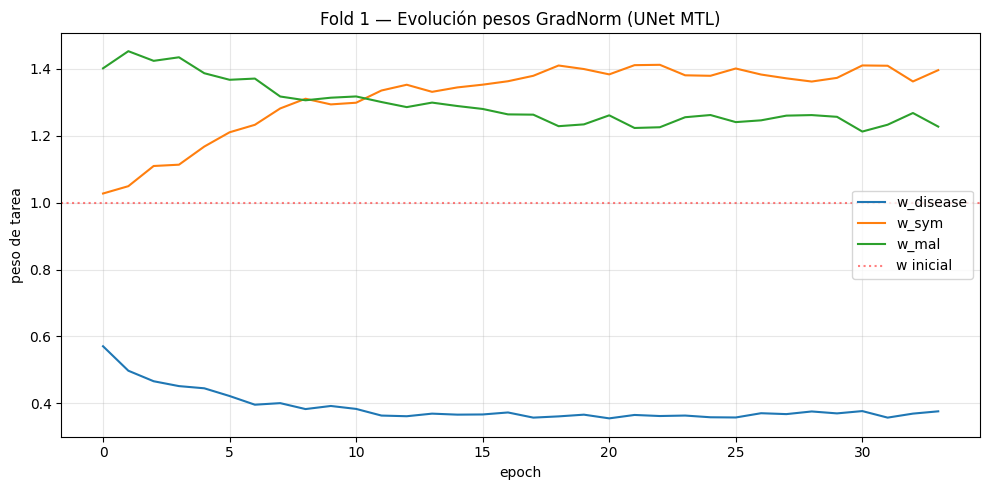


--- Evaluación sobre test (2003 imgs) ---

--- DISEASE ---
              precision    recall  f1-score   support

       akiec     0.3077    0.7273    0.4324        66
         bcc     0.5652    0.6311    0.5963       103
         bkl     0.4316    0.4612    0.4459       219
          df     0.1134    0.4783    0.1833        23
         mel     0.3499    0.6009    0.4422       223
          nv     0.9469    0.6779    0.7901      1341
        vasc     0.3966    0.8214    0.5349        28

    accuracy                         0.6445      2003
   macro avg     0.4445    0.6283    0.4893      2003
weighted avg     0.7661    0.6445    0.6815      2003



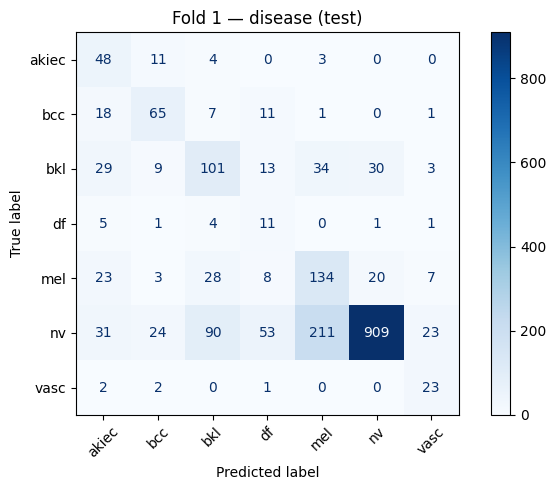


--- SYM ---
              precision    recall  f1-score   support

      2_ejes     0.7149    0.6623    0.6876      1208
       1_eje     0.3243    0.1788    0.2305       604
  asimetrica     0.2069    0.5969    0.3073       191

    accuracy                         0.5102      2003
   macro avg     0.4154    0.4793    0.4085      2003
weighted avg     0.5487    0.5102    0.5135      2003



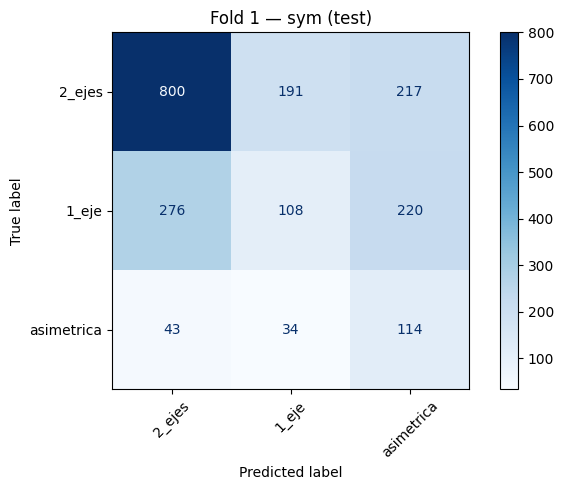


--- MAL ---
              precision    recall  f1-score   support

     benigno     0.9543    0.7784    0.8574      1611
     maligno     0.4819    0.8469    0.6142       392

    accuracy                         0.7918      2003
   macro avg     0.7181    0.8127    0.7358      2003
weighted avg     0.8619    0.7918    0.8098      2003



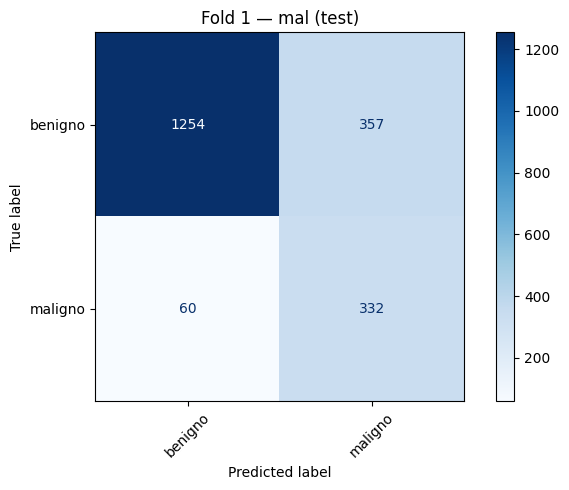

  Pesos guardados en: UNet_MTL/exp_2026-06-24_09-33_5fold/FASE2_final/best_weights

F1 macro test  disease=0.4893  sym=0.4085  mal=0.7358
CSV guardado: UNet_MTL/exp_2026-06-24_09-33_5fold/FASE2_final/predictions_MTL_UNet_FASE2.csv  (2003 filas)


In [9]:
from sklearn.metrics import precision_score, recall_score

MODEL_TAG = "UNet"
EXP_DIR_FASE2 = EXP_DIR / "FASE2_final"
EXP_DIR_FASE2.mkdir(parents=True, exist_ok=True)

n_train   = len(df_train)
train_idx = np.arange(n_train)
val_idx   = np.arange(n_train, len(df_trainval))
print(f"train={len(train_idx)}  val={len(val_idx)}  test={len(df_test)}")

res = train_one_fold(1, train_idx, val_idx, EXP_DIR_FASE2)

# train_one_fold no devuelve s/m proba ni el modelo: recargar pesos y re-predecir.
# El modelo devuelve [disease, sym, mal, reconstruccion]; tomamos las 3 primeras.
backbone2, _ = build_model()
for imgs, _lbl in test_ds.take(1):
    _ = backbone2(imgs[:1], training=False)
backbone2.load_weights(str(EXP_DIR_FASE2 / "best_weights"))
preds = backbone2.predict(test_ds, verbose=0)
y_pred_d_proba, y_pred_s_proba, y_pred_m_proba = preds[0], preds[1], preds[2]
y_pred_d = np.argmax(y_pred_d_proba, axis=1)
y_pred_s = np.argmax(y_pred_s_proba, axis=1)
y_pred_m = np.argmax(y_pred_m_proba, axis=1)


def full_task_metrics(y_true_int, y_pred_int, proba, task, n_cls):
    m = {
        f"{task}_acc":             float((y_true_int == y_pred_int).mean()),
        f"{task}_balanced_acc":    float(balanced_accuracy_score(y_true_int, y_pred_int)),
        f"{task}_precision_macro": float(precision_score(y_true_int, y_pred_int, average="macro", zero_division=0)),
        f"{task}_recall_macro":    float(recall_score(y_true_int, y_pred_int, average="macro", zero_division=0)),
        f"{task}_f1_macro":        float(f1_score(y_true_int, y_pred_int, average="macro", zero_division=0)),
        f"{task}_f1_weighted":     float(f1_score(y_true_int, y_pred_int, average="weighted", zero_division=0)),
        f"{task}_kappa":           float(cohen_kappa_score(y_true_int, y_pred_int)),
    }
    try:
        m[f"{task}_auc_macro"] = float(roc_auc_score(np.eye(n_cls)[y_true_int], proba,
                                                     multi_class="ovr", average="macro"))
    except Exception:
        m[f"{task}_auc_macro"] = float("nan")
    return m

metrics = {
    "model":           MODEL_TAG,
    "final_w_disease": res["metrics"]["final_w_disease"],
    "final_w_sym":     res["metrics"]["final_w_sym"],
    "final_w_mal":     res["metrics"]["final_w_mal"],
    "epochs_trained":  res["metrics"]["epochs_trained"],
    "time_train_s":    res["metrics"]["time_train_s"],
}
metrics.update(full_task_metrics(y_test_disease_int, y_pred_d, y_pred_d_proba, "disease", NUM_CLASSES))
metrics.update(full_task_metrics(y_test_sym_int,     y_pred_s, y_pred_s_proba, "sym",     NUM_SYM_CLASSES))
metrics.update(full_task_metrics(y_test_mal_int,     y_pred_m, y_pred_m_proba, "mal",     NUM_MAL_CLASSES))
metrics["auc_melanoma"] = float(roc_auc_score((y_test_disease_int == 4).astype(int), y_pred_d_proba[:, 4]))

pd.DataFrame([metrics]).to_csv(EXP_DIR_FASE2 / "metrics_FASE2.csv", index=False)
(EXP_DIR_FASE2 / "metrics_FASE2.json").write_text(json.dumps(metrics, indent=2))
print(f"\nF1 macro test  disease={metrics['disease_f1_macro']:.4f}  "
      f"sym={metrics['sym_f1_macro']:.4f}  mal={metrics['mal_f1_macro']:.4f}")

# CSV imagen a imagen, 3 tareas
df_pred = pd.DataFrame({"image_id": df_test["image_id"].values})
df_pred["disease_true_idx"] = y_test_disease_int; df_pred["disease_pred_idx"] = y_pred_d
df_pred["disease_true"] = [class_names[i] for i in y_test_disease_int]
df_pred["disease_pred"] = [class_names[i] for i in y_pred_d]
df_pred["sym_true_idx"] = y_test_sym_int; df_pred["sym_pred_idx"] = y_pred_s
df_pred["sym_true"] = [sym_names[i] for i in y_test_sym_int]
df_pred["sym_pred"] = [sym_names[i] for i in y_pred_s]
df_pred["mal_true_idx"] = y_test_mal_int; df_pred["mal_pred_idx"] = y_pred_m
df_pred["mal_true"] = [mal_names[i] for i in y_test_mal_int]
df_pred["mal_pred"] = [mal_names[i] for i in y_pred_m]
for j, c in enumerate(class_names): df_pred[f"prob_disease_{c}"] = y_pred_d_proba[:, j]
for j, c in enumerate(sym_names):   df_pred[f"prob_sym_{c}"]     = y_pred_s_proba[:, j]
for j, c in enumerate(mal_names):   df_pred[f"prob_mal_{c}"]     = y_pred_m_proba[:, j]
out_csv = EXP_DIR_FASE2 / f"predictions_MTL_{MODEL_TAG}_FASE2.csv"
df_pred.to_csv(out_csv, index=False)
print(f"CSV guardado: {out_csv}  ({len(df_pred)} filas)")